In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
# STEP 1: GIVEN SPEECH SIGNALS
# Signal 1 (Reference) is shorter – spoken faster.
# Signal 2 (Test) is longer – spoken slower.
# Speech duration differences cause misalignment, so LTN is required.
signal1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])
signal2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])

t1 = np.linspace(0, 1, len(signal1))
t2 = np.linspace(0, 1, len(signal2)) 

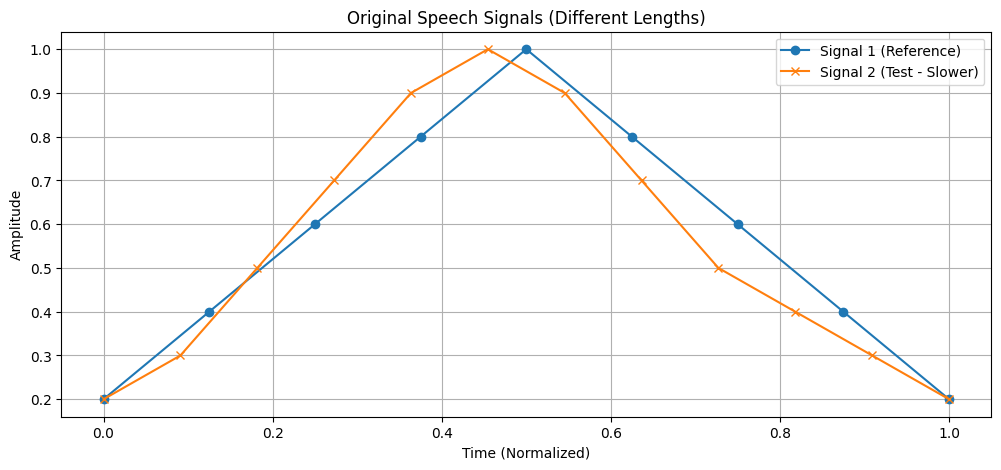

In [3]:
# STEP 2: PLOT ORIGINAL SIGNALS
# The plot shows that Signal 2 has more samples (12 > 9).
# This indicates slower articulation of the same word.
plt.figure(figsize=(12,5))
plt.plot(t1, signal1, marker='o', label='Signal 1 (Reference)')
plt.plot(t2, signal2, marker='x', label='Signal 2 (Test - Slower)')
plt.title("Original Speech Signals (Different Lengths)")
plt.xlabel("Time (Normalized)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
# STEP 3: LINEAR TIME NORMALIZATION (LTN)
# LTN uses linear interpolation to stretch or compress the time axis.
# Here, Signal 2 is compressed from 12 samples → 9 samples to match Signal 1.
# This allows meaningful point-to-point comparison.
interp_func = interp1d(t2, signal2, kind='linear')
signal2_normalized = interp_func(t1) 

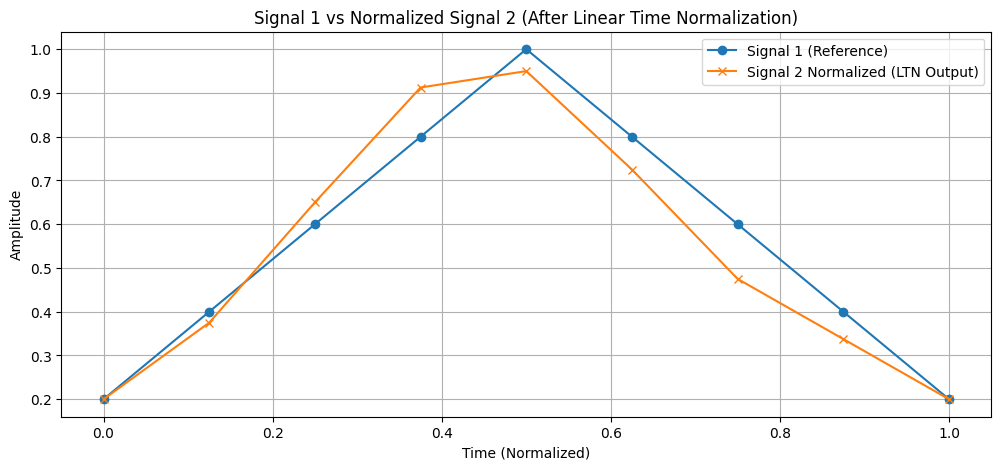

In [6]:
# STEP 4: PLOT NORMALIZED SIGNAL
# After normalization, both signals have equal length.
# Their shapes now appear more similar, meaning LTN has aligned time patterns.
plt.figure(figsize=(12,5))
plt.plot(t1, signal1, marker='o', label='Signal 1 (Reference)')
plt.plot(t1, signal2_normalized, marker='x', label='Signal 2 Normalized (LTN Output)')
plt.title("Signal 1 vs Normalized Signal 2 (After Linear Time Normalization)")
plt.xlabel("Time (Normalized)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show() 

In [7]:
# STEP 5: ALIGNMENT PATH CALCULATION
# After LTN, each sample in Signal 1 now matches exactly one sample in Signal 2.
# This 1-to-1 mapping would not be possible without time normalization.
alignment_indices = list(zip(range(len(signal1)), range(len(signal2_normalized))))


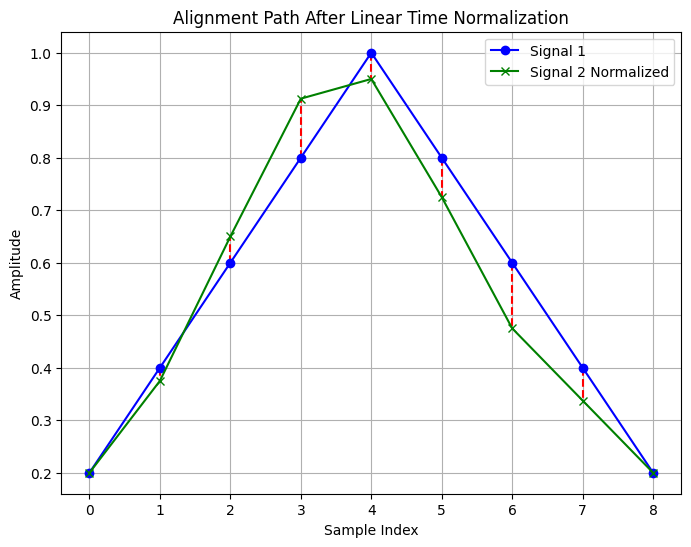

In [8]:
# STEP 6: ALIGNMENT PATH PLOT
# The plotted red dashed lines show how each sample aligns.
# A nearly straight pattern indicates successful alignment between signals.
plt.figure(figsize=(8,6))
for ref_idx, test_idx in alignment_indices:
    plt.plot([ref_idx, test_idx], [signal1[ref_idx], signal2_normalized[test_idx]], 'r--')

plt.plot(signal1, 'bo-', label="Signal 1")
plt.plot(signal2_normalized, 'gx-', label="Signal 2 Normalized")
plt.title("Alignment Path After Linear Time Normalization")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Linear Time Normalization successfully adjusts for differences in speech rate.
# The slower signal (Signal 2) was compressed to match the faster signal (Signal 1).
# This allows accurate comparison of amplitude patterns and temporal structure.
# LTN ensures that similar spoken patterns occur at corresponding time positions.